# Case Study 6: Particle Detection with a Dense Neural Network
### Eric Graham
### DS 7333: Quantifying the World
### Dr. Robert Slater

## Introduction

The client has returned with 7 million simulated collision events, each labeled 1 for particle detection and 0 for background, with 27 kinematic features plus a mass hypothesis column. We build a dense neural network in PyTorch Lightning with early stopping and checkpointing, reaching 88.5% accuracy on both the held-out validation and test sets, then demonstrate cross validation on a small subsample and tune regularization, depth, optimizer, and learning rate on a subset.

## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import lightning as L
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

## Data Loading

The file is a single CSV of 7 million rows.

In [2]:
data = pd.read_csv("./all_train.csv", dtype=np.float32)
data = data.rename(columns={"# label": "label"})
print(data.shape)
data.head()

(7000000, 29)


,label,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f18,f19,f20,f21,f22,f23,f24,f25,f26,mass
0,1.0,-0.346368,0.416306,0.999236,0.475342,0.427493,-0.005984,1.989833,0.344530,1.566297,...,4.105282,0.267826,0.378718,1.743123,3.406367,4.350537,-0.352571,1.130032,2.227706,1000.0
1,1.0,1.708236,-0.319394,-1.241873,-0.887231,-0.871906,-0.005984,-0.001047,-1.038225,0.655748,...,-1.178141,-0.877361,-1.483769,-0.573682,-1.693781,-0.545062,-0.299118,-0.662942,-0.193019,750.0
2,0.0,-0.360693,1.794174,0.264738,-0.472273,-0.292344,-1.054221,-1.150495,1.423404,1.270098,...,-1.199511,0.539020,-1.590629,-0.573682,-0.543636,-0.937456,-0.300344,-0.523262,-1.506304,750.0
3,1.0,-0.377914,-0.103932,-0.649434,-2.125015,-1.643797,-0.005984,1.011112,-1.040340,-0.541991,...,0.463763,-0.006583,1.089122,-0.573682,-0.276348,-0.409272,-0.349926,-0.307123,0.529698,1250.0
4,0.0,-0.067436,-0.636762,-0.620166,-0.062551,1.588715,-0.005984,-0.595304,-1.238987,0.336844,...,-0.552837,-1.418494,-0.562982,1.743123,0.881802,0.002516,1.560950,-0.150760,-1.023889,750.0


## EDA

The classes are close to balanced, so accuracy is a reasonable headline metric and no resampling is needed.

In [3]:
data["label"].value_counts()

label
1.0    3500879
0.0    3499121
Name: count, dtype: int64

In [4]:
data.isna().sum().sum()

np.int64(0)

The kinematic features arrive already standardized (means near 0, standard deviations near 1). The mass column is the hypothesis mass of the simulated particle and takes only five discrete values from 500 to 1500, so we standardize it to match the other features before modeling.

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
label,7000000.0,0.500126,0.500000,0.000000,0.000000,1.000000,1.000000,1.000000
f0,7000000.0,0.016125,1.004417,-1.960549,-0.728821,-0.039303,0.690080,4.378282
f1,7000000.0,0.000477,0.997486,-2.365355,-0.733255,0.000852,0.734783,2.365287
f2,7000000.0,0.000027,1.000080,-1.732165,-0.865670,0.000320,0.865946,1.732370
f3,7000000.0,0.010561,0.995600,-9.980274,-0.609229,0.019633,0.679882,4.148023
f4,7000000.0,-0.000105,0.999867,-1.732137,-0.865802,-0.000507,0.865765,1.731978
f5,7000000.0,0.002766,1.000957,-1.054221,-1.054221,-0.005984,0.850488,4.482618
f6,7000000.0,0.018160,0.986775,-3.034787,-0.756609,-0.149953,0.768669,3.720345
f7,7000000.0,0.000025,0.996587,-2.757853,-0.701415,-0.000107,0.701319,2.758590
f8,7000000.0,0.000435,1.000007,-1.732359,-0.865654,0.001385,0.866598,1.731450


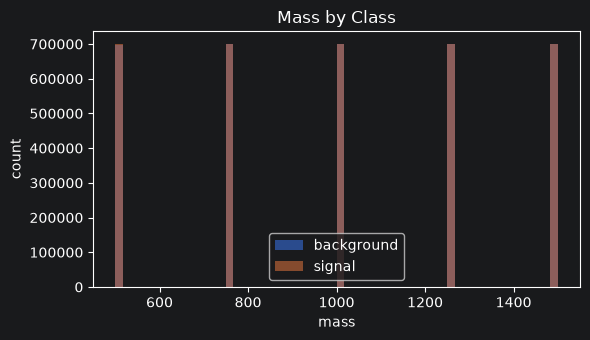

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(data.loc[data["label"] == 0, "mass"], bins=60, alpha=0.6, label="background")
ax.hist(data.loc[data["label"] == 1, "mass"], bins=60, alpha=0.6, label="signal")
ax.set_xlabel("mass")
ax.set_ylabel("count")
ax.set_title("Mass by Class")
ax.legend()
plt.tight_layout()
plt.show()

## Train/Validation/Test Split

We split 60/20/20 as required, then standardize mass with a scaler fit on the training set only to avoid leakage.

In [7]:
train_data, test_data = train_test_split(data, test_size=0.2, shuffle=True, random_state=14)
train_data, val_data = train_test_split(train_data, test_size=0.25, shuffle=True, random_state=14)
train_data = train_data.copy()
val_data = val_data.copy()
test_data = test_data.copy()

scaler = StandardScaler()
train_data["mass"] = scaler.fit_transform(train_data[["mass"]])
val_data["mass"] = scaler.transform(val_data[["mass"]])
test_data["mass"] = scaler.transform(test_data[["mass"]])
print(len(train_data), len(val_data), len(test_data))

4200000 1400000 1400000


## Dataset and DataLoaders

We use the Dataset pattern from the guidelines. A batch size of 4096 keeps an epoch over 4.2 million rows to about 1,000 steps.

In [8]:
class SimpleDataset(Dataset):
    def __init__(self, input_dataframe, target="label"):
        self.data = input_dataframe
        self.target = target
        self.x = np.array(input_dataframe.drop(columns=[self.target]))
        self.y = np.array(input_dataframe[self.target])

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        feature = self.x[idx, :]
        target = self.y[idx]
        return torch.tensor(feature, dtype=torch.float), torch.tensor([target], dtype=torch.float)

In [9]:
BATCH_SIZE = 4096
train_dataset = SimpleDataset(train_data)
val_dataset = SimpleDataset(val_data)
test_dataset = SimpleDataset(test_data)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

## Model

The network takes all 28 features through three hidden layers (256, 128, 64) with ReLU activations to a single output logit. We use binary cross entropy as the loss since this is binary detection: it directly optimizes the log likelihood of the labels, and the `BCEWithLogitsLoss` form combines the sigmoid and loss in one numerically stable step while still letting us recover probabilities at prediction time. We also log accuracy since the classes are balanced and accuracy is the client's stated goal.

In [10]:
input_size = 28

class ParticleNet(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.loss = nn.BCEWithLogitsLoss()
        self.layer1 = nn.Linear(input_size, 256)
        self.layer2 = nn.Linear(256, 128)
        self.layer3 = nn.Linear(128, 64)
        self.layer4 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        a1 = self.relu(self.layer1(x))
        a2 = self.relu(self.layer2(a1))
        a3 = self.relu(self.layer3(a2))
        return self.layer4(a3)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss(y_hat, y)
        acc = ((torch.sigmoid(y_hat) > 0.5) == y.bool()).float().mean()
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss(y_hat, y)
        acc = ((torch.sigmoid(y_hat) > 0.5) == y.bool()).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

## Training

Epochs are uncapped (`max_epochs=-1`) so early stopping alone decides when training is done: it watches validation loss and halts after 5 epochs without improvement. The checkpoint callback saves the best model to `MyProfessorIsAJerk/` (although he is not, he is actually great!) with the epoch and validation loss in the filename.

In [11]:
text_logs = CSVLogger("logs/")
es = EarlyStopping(patience=5, monitor="val_loss", mode="min")
model_save = ModelCheckpoint(
    save_top_k=1,
    monitor="val_loss",
    mode="min",
    dirpath="MyProfessorIsAJerk/",
    filename="particle-{epoch:02d}-{val_loss:.4f}",
)

model = ParticleNet()
trainer = L.Trainer(accelerator="cuda", max_epochs=-1, logger=text_logs, callbacks=[es, model_save])
trainer.fit(model, train_dataloader, val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name   | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | loss   | BCEWithLogitsLoss | 0      | train | 0    
1 | layer1 | Linear            | 7.4 K  | train | 0    
2 | layer2 | Linear            | 32.9 K | train

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/eric/data/school/ds_7333_quantifying_the_world/code/case_study_06/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## Training Diagnostics

Training and validation loss track together closely for the whole run, with the best validation loss (0.2574) at epoch 35 and only a small train/validation gap (0.2507 vs 0.2574), so the model is not meaningfully overfitting. We know training is finished because validation loss then went five consecutive epochs without improving, triggering early stopping at epoch 40; the checkpoint keeps epoch 35, so anything after the plateau is discarded.

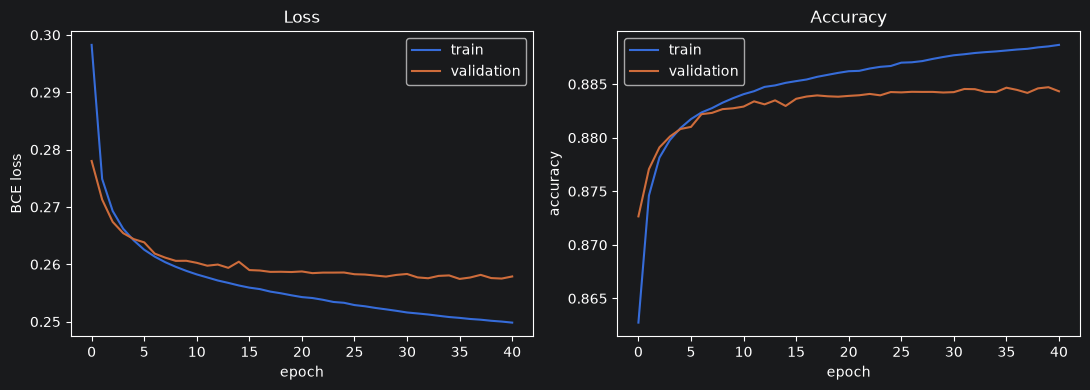

In [12]:
metrics = pd.read_csv(os.path.join(trainer.logger.log_dir, "metrics.csv"))
epoch_metrics = metrics.groupby("epoch")[["train_loss", "val_loss", "train_acc", "val_acc"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epoch_metrics.index, epoch_metrics["train_loss"], label="train")
axes[0].plot(epoch_metrics.index, epoch_metrics["val_loss"], label="validation")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(epoch_metrics.index, epoch_metrics["train_acc"], label="train")
axes[1].plot(epoch_metrics.index, epoch_metrics["val_acc"], label="validation")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

## Best Checkpoint

The best model is `particle-epoch=35-val_loss=0.2574.ckpt` at 582 KB (0.57 MB).

In [13]:
best_path = model_save.best_model_path
size_kb = os.path.getsize(best_path) / 1024
print(best_path)
print(f"{size_kb:.0f} KB ({size_kb / 1024:.2f} MB)")

/mnt/data/school/ds_7333_quantifying_the_world/code/case_study_06/MyProfessorIsAJerk/particle-epoch=35-val_loss=0.2574.ckpt
582 KB (0.57 MB)


## Loading the Checkpoint and Predicting

We load the model back from the saved checkpoint and produce a probability and a class for every instance in the validation and test sets.

In [14]:
best_model = ParticleNet.load_from_checkpoint(best_path).to("cuda")
best_model.eval()

val_probs = []
with torch.no_grad():
    for x, y in val_dataloader:
        val_probs.append(torch.sigmoid(best_model(x.to("cuda"))).cpu())
val_probs = torch.cat(val_probs).numpy().ravel()
val_preds = (val_probs > 0.5).astype(int)
y_val = val_data["label"].to_numpy().astype(int)

test_probs = []
with torch.no_grad():
    for x, y in test_dataloader:
        test_probs.append(torch.sigmoid(best_model(x.to("cuda"))).cpu())
test_probs = torch.cat(test_probs).numpy().ravel()
test_preds = (test_probs > 0.5).astype(int)
y_test = test_data["label"].to_numpy().astype(int)

pd.DataFrame({"probability": test_probs, "class": test_preds}).head()

,probability,class
0,0.321401,0
1,0.998664,1
2,0.244499,0
3,0.284844,0
4,0.956096,1


## Validation Set Report

              precision    recall  f1-score   support

           0     0.9023    0.8626    0.8820    699646
           1     0.8685    0.9067    0.8872    700354

    accuracy                         0.8847   1400000
   macro avg     0.8854    0.8847    0.8846   1400000
weighted avg     0.8854    0.8847    0.8846   1400000



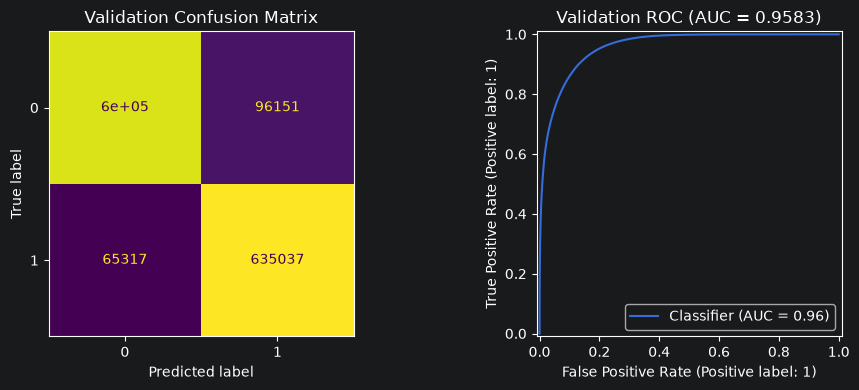

In [15]:
print(classification_report(y_val, val_preds, digits=4))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_val, val_preds, ax=axes[0], colorbar=False)
RocCurveDisplay.from_predictions(y_val, val_probs, ax=axes[1])
axes[0].set_title("Validation Confusion Matrix")
axes[1].set_title(f"Validation ROC (AUC = {roc_auc_score(y_val, val_probs):.4f})")
plt.tight_layout()
plt.show()

## Test Set Report

              precision    recall  f1-score   support

           0     0.9026    0.8626    0.8821    699282
           1     0.8687    0.9071    0.8875    700718

    accuracy                         0.8849   1400000
   macro avg     0.8856    0.8848    0.8848   1400000
weighted avg     0.8856    0.8849    0.8848   1400000



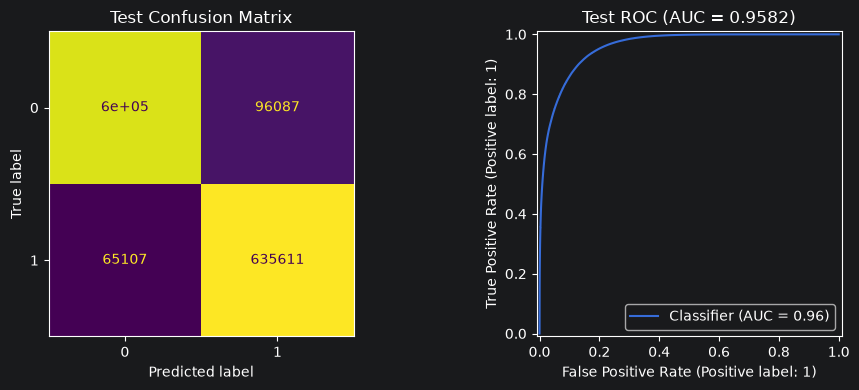

In [16]:
print(classification_report(y_test, test_preds, digits=4))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, ax=axes[0], colorbar=False)
RocCurveDisplay.from_predictions(y_test, test_probs, ax=axes[1])
axes[0].set_title("Test Confusion Matrix")
axes[1].set_title(f"Test ROC (AUC = {roc_auc_score(y_test, test_probs):.4f})")
plt.tight_layout()
plt.show()

## Cross Validation Proof of Concept

We demonstrate cross validation on a 10,000 row subsample with a small network (two hidden layers of 10 neurons), building the folds dynamically with KFold. Each fold trains its own model with early stopping and predicts its held-out fold, giving a cross validated prediction for every row.

In [17]:
class SmallNet(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.loss = nn.BCEWithLogitsLoss()
        self.layer1 = nn.Linear(input_size, 10)
        self.layer2 = nn.Linear(10, 10)
        self.layer3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        a1 = self.relu(self.layer1(x))
        a2 = self.relu(self.layer2(a1))
        return self.layer3(a2)

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss(self(x), y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss(self(x), y)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

In [18]:
small_data = train_data.sample(n=10000, random_state=14).reset_index(drop=True)

kf = KFold(n_splits=5, shuffle=True, random_state=14)
cv_probs = np.zeros(len(small_data))
stop_epochs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(small_data)):
    fold_train_loader = DataLoader(SimpleDataset(small_data.iloc[train_idx]), batch_size=256, shuffle=True)
    fold_val_loader = DataLoader(SimpleDataset(small_data.iloc[val_idx]), batch_size=256, shuffle=False)
    fold_model = SmallNet()
    fold_es = EarlyStopping(patience=5, monitor="val_loss", mode="min")
    fold_trainer = L.Trainer(accelerator="cuda", max_epochs=-1, callbacks=[fold_es],
                             logger=False, enable_checkpointing=False,
                             enable_progress_bar=False, enable_model_summary=False)
    fold_trainer.fit(fold_model, fold_train_loader, fold_val_loader)
    stop_epochs.append(fold_trainer.current_epoch)

    fold_model = fold_model.to("cuda")
    fold_model.eval()
    probs = []
    with torch.no_grad():
        for x, y in fold_val_loader:
            probs.append(torch.sigmoid(fold_model(x.to("cuda"))).cpu())
    cv_probs[val_idx] = torch.cat(probs).numpy().ravel()

print("stopping epoch per fold:", stop_epochs)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/eric/data/school/ds_7333_quantifying_the_world/code/case_study_06/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/eric/data/school/ds_7333_quantifying_the_world/code/case_study_06/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/home/eric/dat

stopping epoch per fold: [62, 52, 63, 45, 63]


In [19]:
cv_preds = (cv_probs > 0.5).astype(int)
y_small = small_data["label"].to_numpy().astype(int)
print(classification_report(y_small, cv_preds, digits=4))

              precision    recall  f1-score   support

           0     0.8730    0.8009    0.8354      4942
           1     0.8200    0.8861    0.8518      5058

    accuracy                         0.8440     10000
   macro avg     0.8465    0.8435    0.8436     10000
weighted avg     0.8462    0.8440    0.8437     10000



The folds stopped at epochs 45 through 63, not at the same point, and that is what we should expect. Each fold trains on a different 8,000 row sample from different random initial weights and monitors validation loss on a different 2,000 row fold (identical stopping points across folds would be the suspicious outcome). The spread is a useful reminder that the stopping epoch is a random variable, which is exactly why early stopping must live inside each fold rather than being fixed to one run's epoch count. The cross validated accuracy of 84.4% is below the big model's 88.5%, as expected from a far smaller network and 400 times less data.

## Tuning Experiments

Using a 100,000 row subset with an 80/20 train/validation split, we change one architectural variable at a time from a baseline of 3 hidden layers of 64 neurons, AdamW with no weight decay, no dropout, and learning rate 1e-3: L2 regularization strength, dropout rate, depth (3 to 5 layers), optimizer family (SGD, AdamW, RMSprop), and learning rate. Every run uses the same early stopping rule, and we score the final weights on the validation split.

In [20]:
class TuneNet(L.LightningModule):
    def __init__(self, n_layers=3, dropout=0.0, weight_decay=0.0, optimizer="adamw", lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.loss = nn.BCEWithLogitsLoss()
        layers = []
        in_size = input_size
        for i in range(n_layers):
            layers.append(nn.Linear(in_size, 64))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_size = 64
        layers.append(nn.Linear(64, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss(self(x), y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss(y_hat, y)
        acc = ((torch.sigmoid(y_hat) > 0.5) == y.bool()).float().mean()
        self.log("val_loss", loss)
        self.log("val_acc", acc)
        return loss

    def configure_optimizers(self):
        if self.hparams.optimizer == "sgd":
            return optim.SGD(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        if self.hparams.optimizer == "rmsprop":
            return optim.RMSprop(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        return optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)

In [21]:
tune_data = train_data.sample(n=100000, random_state=14).reset_index(drop=True)
tune_train, tune_val = train_test_split(tune_data, test_size=0.2, shuffle=True, random_state=14)
tune_train_loader = DataLoader(SimpleDataset(tune_train), batch_size=1024, shuffle=True, num_workers=4)
tune_val_loader = DataLoader(SimpleDataset(tune_val), batch_size=1024, shuffle=False, num_workers=4)

experiments = [
    {"name": "baseline"},
    {"name": "L2 1e-4", "weight_decay": 1e-4},
    {"name": "L2 1e-2", "weight_decay": 1e-2},
    {"name": "dropout 0.2", "dropout": 0.2},
    {"name": "dropout 0.5", "dropout": 0.5},
    {"name": "4 layers", "n_layers": 4},
    {"name": "5 layers", "n_layers": 5},
    {"name": "SGD", "optimizer": "sgd"},
    {"name": "RMSprop", "optimizer": "rmsprop"},
    {"name": "lr 1e-2", "lr": 1e-2},
    {"name": "lr 1e-4", "lr": 1e-4},
]

results = []
for exp in experiments:
    params = {k: v for k, v in exp.items() if k != "name"}
    tune_model = TuneNet(**params)
    tune_es = EarlyStopping(patience=5, monitor="val_loss", mode="min")
    tune_trainer = L.Trainer(accelerator="cuda", max_epochs=-1, callbacks=[tune_es],
                             logger=False, enable_checkpointing=False,
                             enable_progress_bar=False, enable_model_summary=False)
    tune_trainer.fit(tune_model, tune_train_loader, tune_val_loader)
    scores = tune_trainer.validate(tune_model, tune_val_loader, verbose=False)[0]
    results.append({"experiment": exp["name"], "stop_epoch": tune_trainer.current_epoch,
                    "val_loss": scores["val_loss"], "val_acc": scores["val_acc"]})

pd.DataFrame(results)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/eric/data/school/ds_7333_quantifying_the_world/code/case_study_06/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_

,experiment,stop_epoch,val_loss,val_acc
0,baseline,21,0.301849,0.85915
1,L2 1e-4,27,0.297792,0.86210
2,L2 1e-2,24,0.302518,0.85980
3,dropout 0.2,46,0.294622,0.86310
4,dropout 0.5,55,0.300928,0.85865
5,4 layers,25,0.300945,0.86025
6,5 layers,18,0.301352,0.85965
7,SGD,3569,0.307444,0.85565
8,RMSprop,26,0.308311,0.85490
9,lr 1e-2,18,0.305128,0.86520


Mild regularization helps: L2 at 1e-4 and dropout at 0.2 both edge out the baseline. SGD at this learning rate crawled for 3,569 epochs and still finished worse than AdamW's 21, while RMSprop landed close to AdamW but slightly behind. On learning rate, 1e-2 posted the best accuracy but the worse loss of the three, and 1e-4 needed 118 epochs to match the baseline, so 1e-3 is a sensible middle. All differences are within about 0.6 points, supporting the main model's choices of Adam at 1e-3 with little to no regularization, especially since the full 4.2 million row training set showed almost no train/validation gap.

## Conclusion

The final dense network (three hidden layers of 256, 128, and 64 neurons, Adam at 1e-3) reached 88.5% accuracy on both the 1.4 million row validation and test sets, with near-identical classification reports confirming the model generalizes. With epochs uncapped, early stopping halted the run at epoch 40 after validation loss went five epochs without improving, and the saved checkpoint `particle-epoch=35-val_loss=0.2574.ckpt` (582 KB) preserves the best epoch. The tuning study supported these decisions, showing adaptive optimizers outperform plain SGD at a fixed learning rate and only mild regularization is warranted given the negligible train/validation gap. T